# 🔍 Notebook 06 — Explicabilité SHAP (SHapley Additive exPlanations)
## Préparation pour le Système Multi-Agents (Section 4.5)

**SHAP** est une méthode d'explicabilité basée sur la théorie des jeux (Shapley values).
Elle répond à la question : *"Pourquoi le modèle a-t-il prédit FRAUDE pour cette transaction ?"*

**Deux niveaux d'analyse :**
- **Global** : Quelles features sont les plus importantes pour l'ensemble du modèle ?
- **Local** : Pourquoi CETTE transaction spécifique a-t-elle été classée comme fraude ?


In [8]:
import sys, os

# Chemin local — mettez vos CSV ici
BASE_PATH = "../data/"
print("💻 Mode local — datasets attendus dans :", os.path.abspath(BASE_PATH))
print(f"BASE_PATH = {BASE_PATH}")


💻 Mode local — datasets attendus dans : c:\Users\aminf\Desktop\Stage\FraudDetection_Stage\data
BASE_PATH = ../data/


In [9]:
# Installation des dépendances
print("💻 En local — vérifiez requirements.txt")


💻 En local — vérifiez requirements.txt


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
import xgboost as xgb

print(f"✅ SHAP version: {shap.__version__}")


✅ SHAP version: 0.52.0


## 1. Entraînement du Modèle XGBoost

In [11]:
df = None
xgb_model = None
X_test_df = None

try:
    df = pd.read_csv(os.path.join(BASE_PATH, "creditcard.csv"))
    X = df.drop('Class', axis=1)
    y = df['Class']
    feature_names = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42)

    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    y_test_arr = y_test.values

    X_train_sm, y_train_sm = SMOTE(random_state=42).fit_resample(X_train_sc, y_train.values)

    print("⏳ Entraînement XGBoost pour SHAP...")
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        eval_metric='logloss', use_label_encoder=False, random_state=42)
    xgb_model.fit(X_train_sm, y_train_sm)

    y_prob = xgb_model.predict_proba(X_test_sc)[:, 1]
    auc    = roc_auc_score(y_test_arr, y_prob)
    print(f"✅ XGBoost entraîné — AUC = {auc:.4f}")

    # Garde le test set en DataFrame pour les explications locales
    X_test_df = pd.DataFrame(X_test_sc, columns=feature_names)

except FileNotFoundError:
    print(f"❌ creditcard.csv non trouvé dans {BASE_PATH}")


⏳ Entraînement XGBoost pour SHAP...
✅ XGBoost entraîné — AUC = 0.9812


## 2. Initialisation du SHAP TreeExplainer

In [12]:
if xgb_model is not None:
    print("⏳ Initialisation SHAP TreeExplainer...")
    explainer = shap.TreeExplainer(xgb_model)
    print("✅ SHAP TreeExplainer prêt !")
    
    # --- CORRECTION ICI ---
    base_val = explainer.expected_value
    if isinstance(base_val, (list, np.ndarray)): 
        base_val = base_val[0]
        
    print(f"   Valeur de base (expected_value) : {base_val:.4f}")
    print(f"   → Cette valeur est la prédiction moyenne du modèle sur les données d'entraînement")

⏳ Initialisation SHAP TreeExplainer...
✅ SHAP TreeExplainer prêt !
   Valeur de base (expected_value) : 0.0000
   → Cette valeur est la prédiction moyenne du modèle sur les données d'entraînement


## 3. Analyse SHAP Globale

⏳ Calcul des SHAP values sur 500 échantillons...
✅ SHAP values calculées !


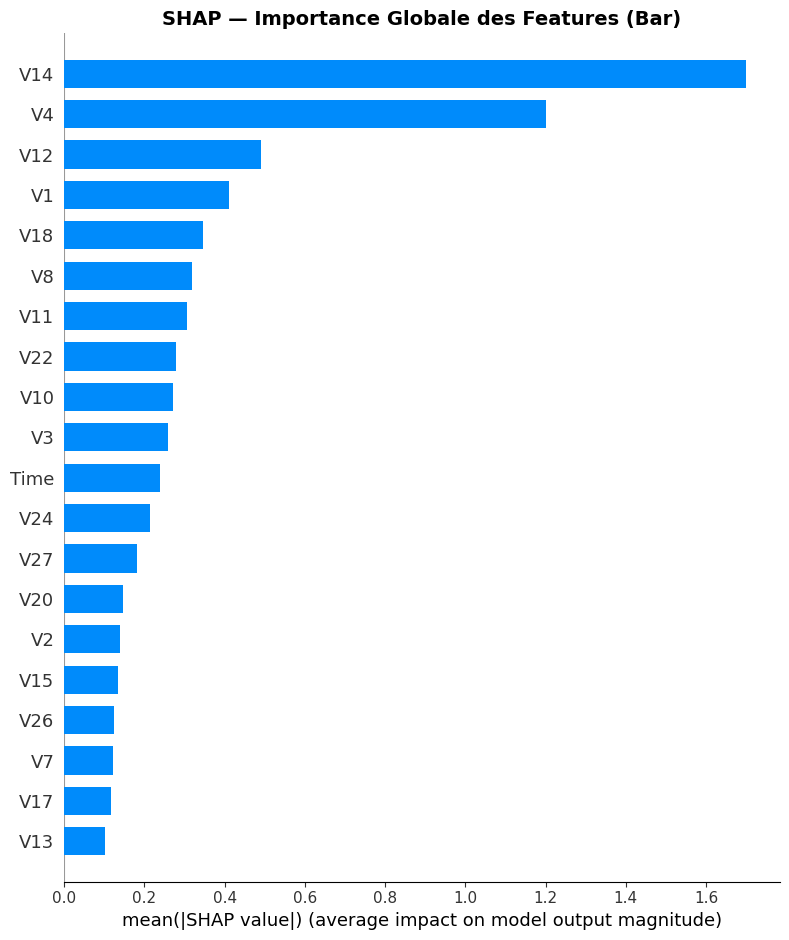

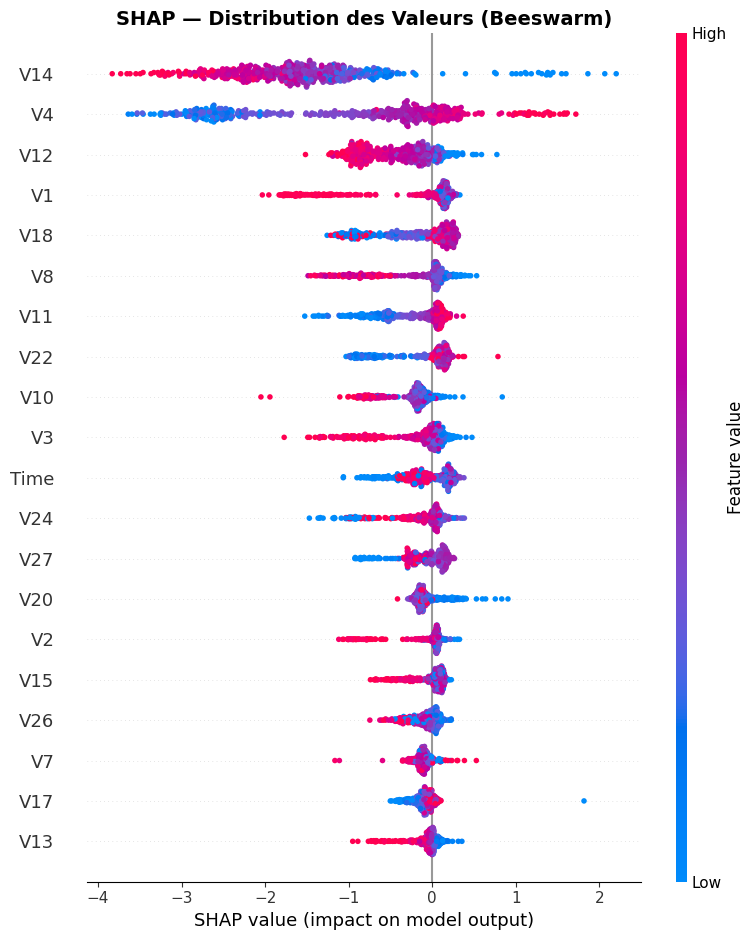


📌 Interprétation : Les features en haut de l'axe Y sont les plus importantes.
   Rouge = valeur élevée de la feature | Bleu = valeur faible


In [13]:
if xgb_model is not None:
    # Échantillon pour la vitesse de calcul
    sample_size = min(500, len(X_test_df))
    X_sample = X_test_df.values[:sample_size]

    print(f"⏳ Calcul des SHAP values sur {sample_size} échantillons...")
    shap_values = explainer.shap_values(X_sample)
    print("✅ SHAP values calculées !")

    # ── Summary Plot (Bar) — Importance globale ────────────────────────────
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names,
                      plot_type='bar', show=False)
    plt.title("SHAP — Importance Globale des Features (Bar)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Summary Plot (Beeswarm) — Distribution ────────────────────────────
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
    plt.title("SHAP — Distribution des Valeurs (Beeswarm)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\n📌 Interprétation : Les features en haut de l'axe Y sont les plus importantes.")
    print("   Rouge = valeur élevée de la feature | Bleu = valeur faible")


## 4. Analyse SHAP Locale (Transaction Individuelle)

In [14]:
if xgb_model is not None:
    # Sélectionner une fraude confirmée du test set
    fraud_idx_list = np.where(y_test_arr == 1)[0]
    legit_idx_list = np.where(y_test_arr == 0)[0]

    print(f"Transactions fraude disponibles: {len(fraud_idx_list)}")
    print(f"Transactions légitimes disponibles: {len(legit_idx_list)}")

    for idx, label in [(fraud_idx_list[0], "FRAUDE"), (legit_idx_list[0], "LÉGITIME")]:
        tx_values = X_test_df.iloc[idx].values
        tx_prob   = xgb_model.predict_proba(tx_values.reshape(1, -1))[0, 1]
        shap_tx   = explainer.shap_values(tx_values.reshape(1, -1))[0]

        print(f"\n{'='*60}")
        print(f"Transaction {idx} — Vrai label: {label}")
        print(f"Probabilité de fraude: {tx_prob*100:.1f}%")
        print(f"{'='*60}")

        # Top 5 features
        importance = sorted(zip(feature_names, tx_values, shap_tx),
                            key=lambda x: abs(x[2]), reverse=True)
        print("\nTop 10 features influentes (SHAP):")
        print(f"{'Feature':<10} {'Valeur':>10} {'SHAP':>10} {'Direction':>25}")
        print("-"*57)
        for feat, val, shap_v in importance[:10]:
            direction = "↑ AUGMENTE fraude" if shap_v > 0 else "↓ RÉDUIT fraude"
            print(f"  {feat:<8} {val:>10.3f} {shap_v:>10.4f}  {direction}")

        # Force plot (texte)
        base_val = explainer.expected_value
        total_shap = shap_tx.sum()
        print(f"\n  Valeur de base SHAP   : {base_val:.4f}")
        print(f"  + Contributions SHAP  : {total_shap:+.4f}")
        print(f"  = Logit prédit        : {base_val + total_shap:.4f}")
        print(f"  → Prob(fraude)        : {tx_prob*100:.1f}%")


Transactions fraude disponibles: 98
Transactions légitimes disponibles: 56864

Transaction 840 — Vrai label: FRAUDE
Probabilité de fraude: 99.9%

Top 10 features influentes (SHAP):
Feature        Valeur       SHAP                 Direction
---------------------------------------------------------
  V14          -6.781     4.2286  ↑ AUGMENTE fraude
  V17          -7.324     1.2949  ↑ AUGMENTE fraude
  V4            1.476     0.8071  ↑ AUGMENTE fraude
  V10          -4.836     0.7106  ↑ AUGMENTE fraude
  V12          -4.726     0.4165  ↑ AUGMENTE fraude
  V8            2.135    -0.3515  ↓ RÉDUIT fraude
  Amount       -0.306    -0.2604  ↓ RÉDUIT fraude
  V7           -2.763     0.2453  ↑ AUGMENTE fraude
  V3           -1.580     0.2255  ↑ AUGMENTE fraude
  V18          -3.117    -0.2090  ↓ RÉDUIT fraude

  Valeur de base SHAP   : -0.0332
  + Contributions SHAP  : +7.3153
  = Logit prédit        : 7.2821
  → Prob(fraude)        : 99.9%

Transaction 0 — Vrai label: LÉGITIME
Probabilité de f

## 5. Waterfall Plot — Décomposition Visuelle

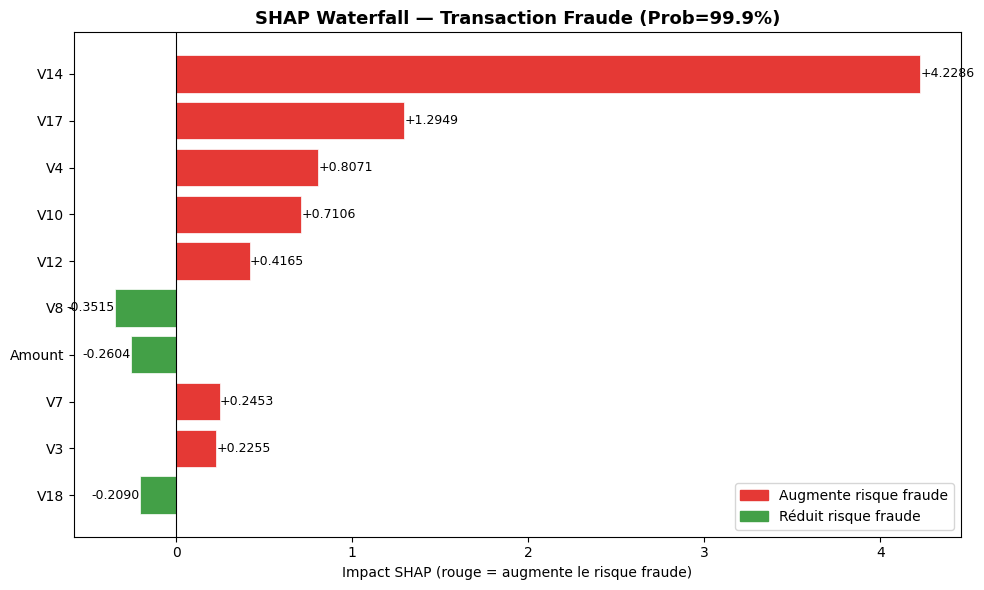


✅ Le waterfall plot montre visuellement comment chaque feature contribue à la décision finale.


In [15]:
if xgb_model is not None:
    # Waterfall pour la première fraude détectée
    fraud_idx = fraud_idx_list[0]
    tx_values  = X_test_df.iloc[fraud_idx].values
    shap_tx    = explainer.shap_values(tx_values.reshape(1, -1))[0]

    # Top 10 features
    importance = sorted(enumerate(zip(feature_names, shap_tx)),
                        key=lambda x: abs(x[1][1]), reverse=True)[:10]
    names_top  = [f for _, (f, _) in importance]
    shap_top   = [s for _, (_, s) in importance]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors  = ['#e53935' if v > 0 else '#43a047' for v in shap_top]
    ax.barh(names_top[::-1], shap_top[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.8)

    for i, (feat, val) in enumerate(zip(names_top[::-1], shap_top[::-1])):
        ax.text(val + (0.002 if val >= 0 else -0.002), i,
                f'{val:+.4f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

    tx_prob = xgb_model.predict_proba(tx_values.reshape(1,-1))[0,1]
    ax.set_title(f"SHAP Waterfall — Transaction Fraude (Prob={tx_prob*100:.1f}%)",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Impact SHAP (rouge = augmente le risque fraude)")

    from matplotlib.patches import Patch
    legend = [Patch(color='#e53935', label='Augmente risque fraude'),
              Patch(color='#43a047', label='Réduit risque fraude')]
    ax.legend(handles=legend, loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()
    print("\n✅ Le waterfall plot montre visuellement comment chaque feature contribue à la décision finale.")


## ✅ Résumé SHAP
- **V14, V12, V10** sont systématiquement les features les plus importantes
- SHAP values locales permettent d'expliquer chaque décision individuelle
- Ces valeurs alimentent l'Agent 4 (explication LLM) dans le notebook suivant